
Import Library/ Package
---



In [42]:
!pip install streamlit

In [43]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import requests
from scipy.stats import ttest_ind
from scipy.stats import shapiro
from google.colab import files
from babel.numbers import format_currency
sns.set(style='dark')
import datetime as dt
plt.style.use('default')

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data Wrangling

Gathering Data

In [45]:
df_bmi= pd.read_csv('/content/drive/MyDrive/Dataset Capstone/500_Person_Gender_Height_Weight_Index.csv')
df_bmi

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3
...,...,...,...,...
495,Female,150,153,5
496,Female,184,121,4
497,Female,141,136,5
498,Male,150,95,5


In [46]:
df_nutrition = pd.read_json('/content/drive/MyDrive/Dataset Capstone/nutrition_data_clean.json')
df_nutrition

,id,calories,proteins,fat,carbohydrate,name,image,food_cluster
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...,1
1,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...,0
2,19,58.0,0.3,0.4,14.9,Apel,https://asset.kompas.com/crops/smfd25xgXRE3HpM...,0
3,37,298.0,34.2,16.8,0.1,Ayam goreng kentucky,https://awsimages.detik.net.id/community/media...,2
4,40,287.0,31.0,15.7,1.7,Ayam goreng,https://cdn1-production-images-kly.akamaized.n...,2
...,...,...,...,...,...,...,...,...
284,1339,355.0,3.2,15.1,51.4,Wingko babat,https://d1vbn70lmn1nqe.cloudfront.net/prod/wp-...,4
285,1341,452.0,14.5,42.3,2.3,Sosis sapi bratwurst,https://www.wikihow.com/images/9/9f/Cook-Sausa...,1
286,1344,28.0,0.7,0.5,6.3,Wortel rebus,https://png.pngtree.com/thumb_back/fw800/backg...,0
287,1345,254.0,3.0,1.1,58.1,Yangko,https://serikatnews.com/wp-content/uploads/202...,4


Asessing Data

df_bmi

In [68]:
df_bmi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 476 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   gender  476 non-null    object
 1   height  476 non-null    int64 
 2   weight  476 non-null    int64 
 3   index   476 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 18.6+ KB


In [69]:
df_bmi.isna().sum()

,0
gender,0
height,0
weight,0
index,0


In [70]:
df_bmi.describe()

,height,weight,index
count,476.000000,476.000000,476.000000
mean,169.434874,107.869748,3.859244
std,16.259927,31.571937,1.218774
min,140.000000,50.000000,1.000000
25%,155.750000,81.000000,3.000000
50%,169.000000,108.000000,4.000000
75%,183.000000,137.000000,5.000000
max,199.000000,160.000000,5.000000


In [50]:
df_bmi[df_bmi['Index']==0]

,Gender,Height,Weight,Index
60,Female,191,54,0
62,Male,193,54,0
79,Male,181,51,0
85,Male,198,50,0
99,Female,190,50,0
150,Female,196,50,0
214,Female,185,52,0
224,Male,188,54,0
244,Female,183,50,0
273,Female,163,57,0


df_nutri

In [71]:
print("Informasi Dataset Nutrisi:")
display(df_nutrition.info())

Informasi Dataset Nutrisi:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            289 non-null    int64  
 1   calories      289 non-null    float64
 2   proteins      289 non-null    float64
 3   fat           289 non-null    float64
 4   carbohydrate  289 non-null    float64
 5   name          289 non-null    object 
 6   image         289 non-null    object 
 7   food_cluster  289 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 18.2+ KB


None

In [72]:
df_nutrition.isna().sum()

,0
id,0
calories,0
proteins,0
fat,0
carbohydrate,0
name,0
image,0
food_cluster,0


Cleaning Data

Cleaning Data BMI

In [73]:
# Standarisasi nama kolom
df_bmi.columns = df_bmi.columns.str.strip().str.lower()

In [74]:
df_bmi = df_bmi.drop_duplicates()

In [75]:
df_bmi.isnull().sum()

,0
gender,0
height,0
weight,0
index,0


In [76]:
# Standarisasi gender
df_bmi['gender'] = df_bmi['gender'].str.lower().str.strip()

In [57]:
df_bmi = df_bmi[df_bmi['index'] != 0]

In [58]:
df_bmi.describe()

,height,weight,index
count,476.000000,476.000000,476.000000
mean,169.434874,107.869748,3.859244
std,16.259927,31.571937,1.218774
min,140.000000,50.000000,1.000000
25%,155.750000,81.000000,3.000000
50%,169.000000,108.000000,4.000000
75%,183.000000,137.000000,5.000000
max,199.000000,160.000000,5.000000


Cleaning Data Nutrition

In [77]:
df_nutrition.head()

,id,calories,proteins,fat,carbohydrate,name,image,food_cluster
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...,1
1,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...,0
2,19,58.0,0.3,0.4,14.9,Apel,https://asset.kompas.com/crops/smfd25xgXRE3HpM...,0
3,37,298.0,34.2,16.8,0.1,Ayam goreng kentucky,https://awsimages.detik.net.id/community/media...,2
4,40,287.0,31.0,15.7,1.7,Ayam goreng,https://cdn1-production-images-kly.akamaized.n...,2


In [60]:
# Mengecek missing value pada data nutrition
df_nutrition.isnull().sum()

,0
id,0
calories,0
proteins,0
fat,0
carbohydrate,0
name,0
image,0
food_cluster,0


In [61]:
df_nutrition.duplicated().sum()


np.int64(0)

In [62]:
invalid_data = df_nutrition[(df_nutrition['calories'] < 0) |
             (df_nutrition['proteins'] < 0) |
             (df_nutrition['fat']) |
             df_nutrition['carbohydrate']<0]
print("Jumlah data yang tidak valid:", len(invalid_data))

Jumlah data yang tidak valid: 0


**TUJUAN BISNIS (Business Objective)**

1. Meningkatkan pengambilan keputusan nutrisi

Banyak aplikasi hanya menampilkan informasi gizi, tapi:

pengguna tetap bingung mau makan apa

➡️ Tujuan:

Memberikan rekomendasi makanan yang actionable
Bukan cuma informasi, tapi keputusan


2. Personalisasi berdasarkan data pengguna

Sistem akan menggunakan:

Berat badan
Tinggi badan
Usia
Target (diet / bulking / maintain)

➡️ Tujuan:

Menentukan kebutuhan kalori harian (BMR & TDEE)
Menyesuaikan rekomendasi makanan


3. Monitoring dan evaluasi pola makan

➡️ Tujuan:

Membantu user tracking:
kalori harian
nutrisi
Memberikan insight:
apakah sudah sesuai target atau belum


4. Mendukung gaya hidup sehat

➡️ Tujuan jangka panjang:

Mengurangi kebiasaan makan tidak sehat
Membantu pengguna mencapai kondisi tubuh ideal

Exploratory Data Analysis (EDA)

**EDA DATASET 1 : NILAI GIZI**

Visualisasi

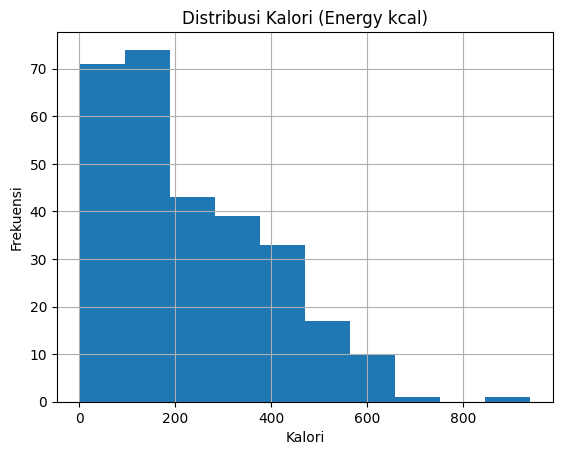

In [63]:
#Distribusi kalori

plt.figure()
df_nutrition['calories'].hist()
plt.title('Distribusi Kalori (Energy kcal)')
plt.xlabel('Kalori')
plt.ylabel('Frekuensi')
plt.show()

In [64]:
#Makanan rendah vs tinggi kalori

low_cal = df_nutrition[df_nutrition['calories'] < 100]
high_cal = df_nutrition[df_nutrition['calories'] > 300]

print("Makanan rendah kalori:", low_cal['name'].head())
print("Makanan tinggi kalori:", high_cal['name'].head())

Makanan rendah kalori: 1       Agar-agar
2            Apel
10          Bakso
12    Bayam kukus
13    Bayam rebus
Name: name, dtype: object
Makanan tinggi kalori: 6     Ayam usus goreng
19        Belut goreng
22             Biskuit
24            Brondong
35        Cassavastick
Name: name, dtype: object


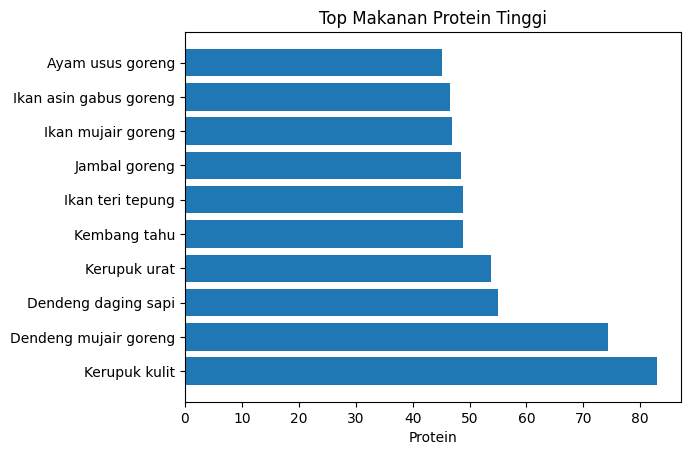

In [65]:
#Top protein untuk bulking

top_protein = df_nutrition.sort_values(by='proteins', ascending=False).head(10)

plt.figure()
plt.barh(top_protein['name'], top_protein['proteins'])
plt.title('Top Makanan Protein Tinggi')
plt.xlabel('Protein')
plt.show()

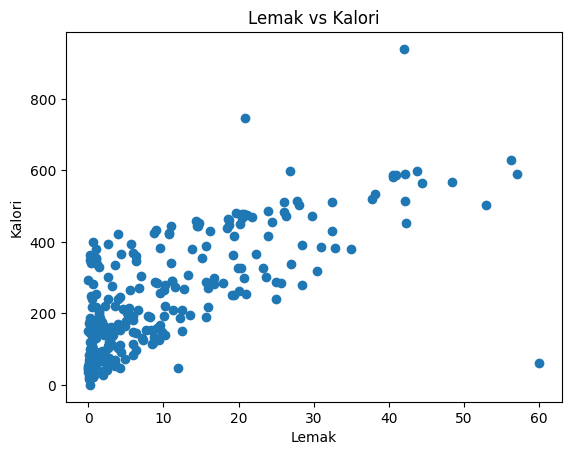

In [66]:
#Hubungan kalori vs lemak

plt.figure()
plt.scatter(df_nutrition['fat'], df_nutrition['calories'])
plt.title('Lemak vs Kalori')
plt.xlabel('Lemak')
plt.ylabel('Kalori')
plt.show()

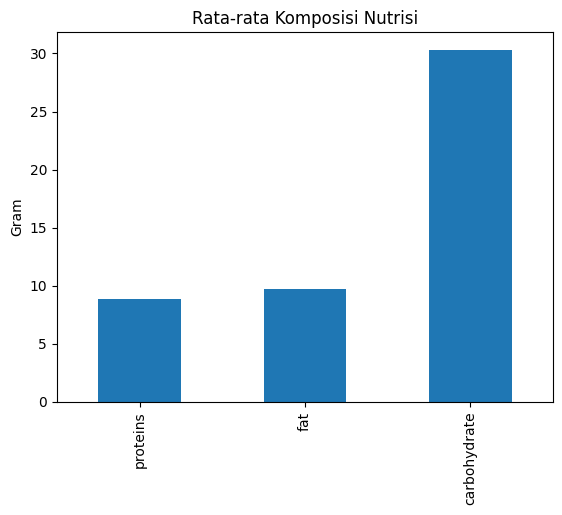

In [82]:
#Komposisi nutrisi (karbo, protein, lemak)

nutrisi = df_nutrition[['proteins','fat','carbohydrate']].mean()

plt.figure()
nutrisi.plot(kind='bar')
plt.title('Rata-rata Komposisi Nutrisi')
plt.ylabel('Gram')
plt.show()

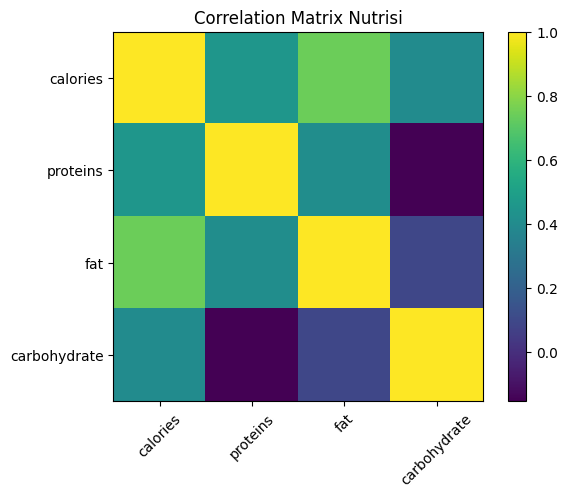

In [98]:
#Korelasi antar nutrisi

corr = df_nutrition[['calories','proteins','fat','carbohydrate']].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix Nutrisi')
plt.show()

**EDA DATASET 2 : BMI**

Visualisasi

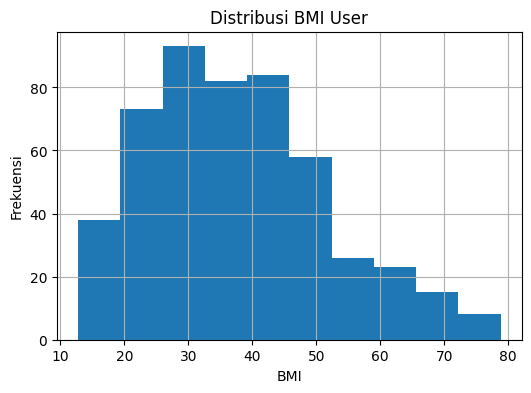

In [99]:

#Distribusi BMI

# Hitung BMI
df_bmi['BMI'] = df_bmi['Weight'] / ((df_bmi['Height']/100)**2)

plt.figure(figsize=(6,4))
df_bmi['BMI'].hist()

plt.title('Distribusi BMI User')
plt.xlabel('BMI')
plt.ylabel('Frekuensi')

plt.show()

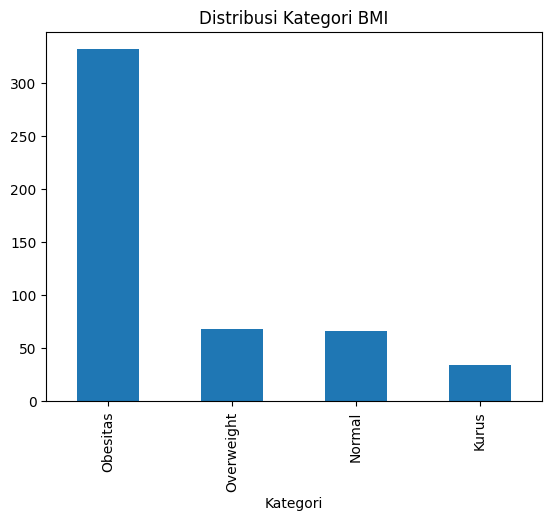

In [100]:
#kategori BMI

def kategori_bmi(bmi):
    if bmi < 18.5:
        return 'Kurus'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obesitas'

df_bmi['Kategori'] = df_bmi['BMI'].apply(kategori_bmi)

df_bmi['Kategori'].value_counts().plot(kind='bar')
plt.title('Distribusi Kategori BMI')
plt.show()

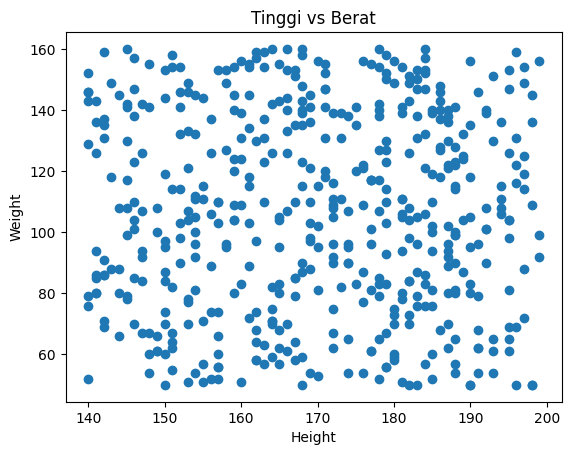

In [102]:
#Scatter Plot height vs weight

plt.figure()
plt.scatter(df_bmi['Height'], df_bmi['Weight'])
plt.title('Tinggi vs Berat')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

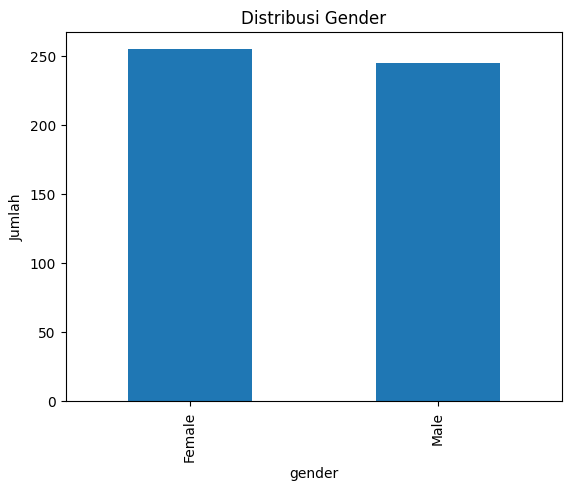

In [104]:
#Distribusi gender

plt.figure()
df_bmi['Gender'].value_counts().plot(kind='bar')
plt.title('Distribusi Gender')
plt.xlabel('gender')
plt.ylabel('Jumlah')
plt.show()

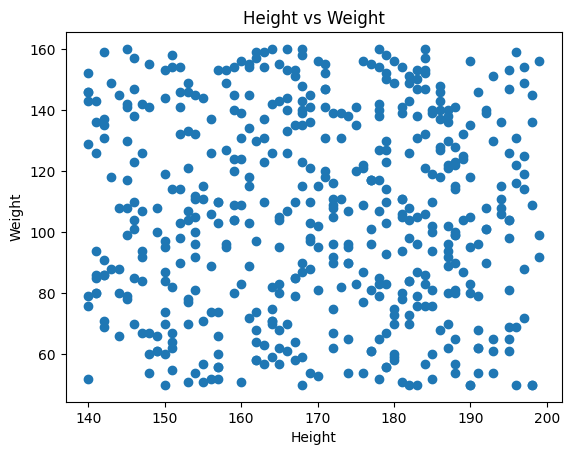

In [105]:
#Scatter plot tinggi vs berat

plt.figure()
plt.scatter(df_bmi['Height'], df_bmi['Weight'])
plt.title('Height vs Weight')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

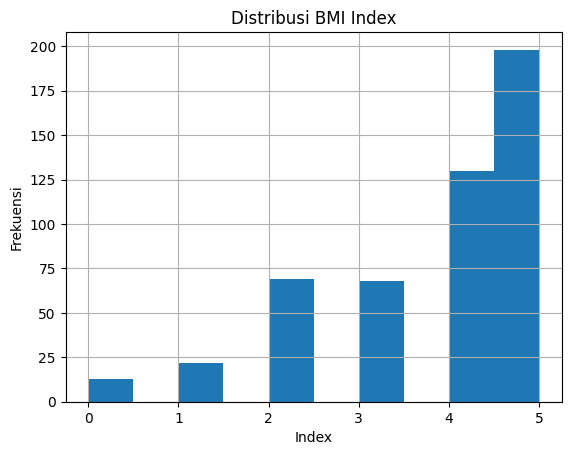

In [107]:
#Distribusi BMI Index

plt.figure()
df_bmi['Index'].hist()
plt.title('Distribusi BMI Index')
plt.xlabel('Index')
plt.ylabel('Frekuensi')
plt.show()

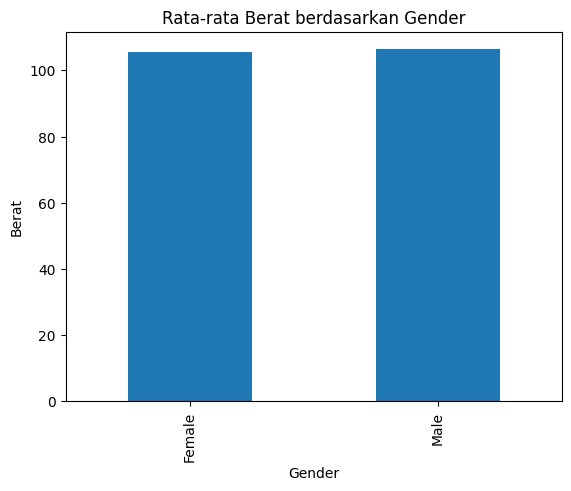

In [108]:
#rata rata berat berdasarkan gender

avg_weight = df_bmi.groupby('Gender')['Weight'].mean()

plt.figure()
avg_weight.plot(kind='bar')
plt.title('Rata-rata Berat berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Berat')
plt.show()

In [111]:
def food_category(row):

  if row['proteins'] >= 15:
    return 'High protein'

  elif row['carbohydrate'] <= 10:
    return 'Low Carb'

  elif row['calories'] <= 150 and row['fat'] <= 10:
    return 'Healthy'

  else:
    return 'Snack'

df_nutrition['food_category'] = df_nutrition.apply(
    food_category,
    axis=1
)



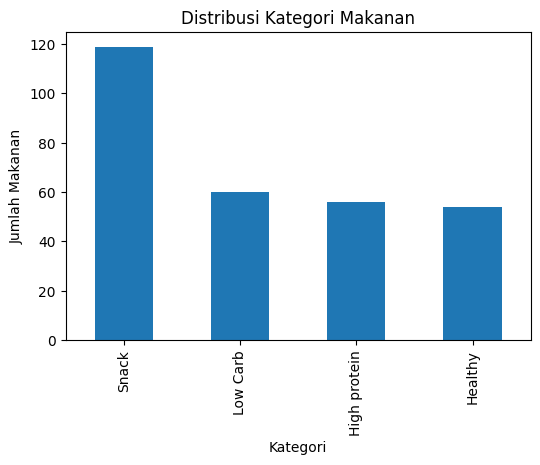

In [132]:
# Distribusi kategori makanan
plt.figure(figsize=(6,4))

df_nutrition['food_category'].value_counts().plot(
    kind='bar'
)

plt.title('Distribusi Kategori Makanan')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Makanan')

plt.show()

In [112]:
print(df_nutrition['food_category'].value_counts())

food_category
Snack           119
Low Carb         60
High protein     56
Healthy          54
Name: count, dtype: int64


In [113]:
df_nutrition[['name', 'food_category']].head()

,name,food_category
0,Abon,Low Carb
1,Agar-agar,Low Carb
2,Apel,Healthy
3,Ayam goreng kentucky,High protein
4,Ayam goreng,High protein


In [114]:
# cek rows dataset
print("df_nutrition:", df_nutrition.shape)
print("df_bmi:", df_bmi.shape)


df_nutrition: (289, 9)
df_bmi: (500, 6)


# A/B TESTING

In [115]:
# Group A -> High Protein
group_a = df_nutrition[df_nutrition['food_category'] == 'High protein']['calories']

In [117]:
# Group B -> Healthy
group_b = df_nutrition[df_nutrition['food_category']=='Healthy']['calories']

Hypotesis

**H0**
Tidak ada perbedaan rata-rata kalori antara makanan High Protein dan Healthy

**H1** Ada perbedaan rata-rata kalori antara makanan High Protein dan Healthy

Running T-Test

In [118]:
# Cek ukuran tiap group
print("Group A (High Protein):", len(group_a))
print("Group B (Healthy):", len(group_b))


Group A (High Protein): 56
Group B (Healthy): 54


In [119]:
# Cek normalitas
stat_a, p_a = shapiro(group_a)
stat_b, p_b = shapiro(group_b)
print(f"\nShapiro-Wilk Group A: stat={stat_a:.4f}, p={p_a:.4f}")
print(f"Shapiro-Wilk Group B: stat={stat_b:.4f}, p={p_b:.4f}")

if p_a > 0.05:
  print("Group A: Distribusi Normal")
else:
  print("Group B: Distribusi Tidak Normal(Welch's t-test tetap robust)")
if p_b > 0.05:
  print("Group B: Distribusi Normal")
else:
  print("Group B: Distribusi Tidak Normal(Welch's t-test tetap robust)")


Shapiro-Wilk Group A: stat=0.9486, p=0.0184
Shapiro-Wilk Group B: stat=0.9160, p=0.0011
Group B: Distribusi Tidak Normal(Welch's t-test tetap robust)
Group B: Distribusi Tidak Normal(Welch's t-test tetap robust)


statistik deskriptif kedua group

In [120]:
desc = pd.DataFrame({
    'Group': ['High Protein', 'Healthy'],
    'N':[len(group_a), len(group_b)],
    'Mean Kalori': [round(group_a.mean(), 2), round(group_b.mean(), 2)],
    'Std': [round(group_a.std(), 2), round(group_b.std(), 2)],
    'Min':[group_a.min(), group_b.min()],
    'Max':[group_a.max(),group_b.max()]
})
print(desc.to_string(index=False))

       Group  N  Mean Kalori    Std   Min   Max
High Protein 56       361.36 169.71 110.0 940.0
     Healthy 54        93.03  34.34  44.8 149.0


In [121]:
def cohen_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std

d = cohen_d(group_a, group_b)
print(f"Cohen's d: {d:.4f}")

if abs(d) < 0.2:
    interpretasi = "Kecil (small effect)"
elif abs(d) < 0.8:
    interpretasi = "Sedang (medium effect)"
else:
    interpretasi = "Besar (large effect)"

print(f"Interpretasi: {interpretasi}")

Cohen's d: 2.1917
Interpretasi: Besar (large effect)


In [122]:
t_stat, p_value = ttest_ind(
    group_a,
    group_b,
    equal_var=False
)

In [123]:
print("=== A/B Testing Result ===")
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

=== A/B Testing Result ===
T-Statistic: 11.588788473350702
P-Value: 6.538614518911964e-17


In [124]:
alpha = 0.05
if p_value < alpha:
  print("Ada perbedaan signifikan antara kedua kelompok makanan")
else:
  print("Tidak ada perbedaan signifikan antara kedua kelompok makanan")

Ada perbedaan signifikan antara kedua kelompok makanan


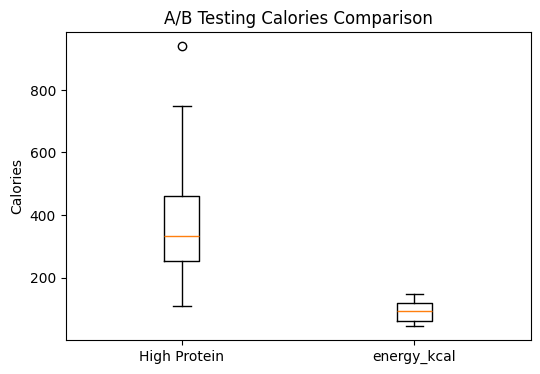

In [125]:
plt.figure(figsize=(6,4))
plt.boxplot([group_a, group_b],
            tick_labels=['High Protein', 'Healthy']
            )
plt.title("A/B Testing Calories Comparison")
plt.ylabel("Calories")
plt.show()

In [126]:
df_nutrition['food_category'].value_counts()

,count
food_category,
Snack,119
Low Carb,60
High protein,56
Healthy,54


# SIMPAN DATA

In [130]:
# simpan df bmi ke csv
df_bmi.to_csv('/content/df_bmi_final.csv',
              index=False)
# simpan df nutrition ke csv
df_nutrition.to_csv('/content/df_nutrition_final.csv',
              index=False)

In [131]:
files.download('df_bmi_final.csv')
files.download('df_nutrition_final.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

1. Berdasarkan hasil hasil Exploratory Data Analysis (EDA), mayoritas makanan dalam dataset termasuk kategori Low Sugar dan Low Carb.

2. Distribusi BMI menunjukkan bahwa sebagian besar pengguna berada pada kategori Normal

3. Hasil visualisasi menunjukkan bahwa kandungan protein, lemak, dan kalori memiliki hubungan terhadap kategori makanan.

4.  Berdasarkan hasil A/B testing menggunakan independent T-Test, Kategori makanan High Protein memiliki distribusi kalori yang lebih tinggi dibanding kategori healthnya.

5. Sistem rekomendasi makanan berbasis BMI berhasil diimplementasikan menggunakan streamlit sehingga pengguna dapat memperoleh rekomendasi makanan sesuai kategori BMI mereka

